Areas with rental data: 121
Areas without rental data: 56

Areas with no rental data:


,Airbnb Properties,Rental Properties
area_code,,
316401,5,NaN
316500,1,NaN
316700,28,NaN
317100,1,NaN
317201,3,NaN
317301,3,NaN
317501,14,NaN
317701,11,NaN
318401,4,NaN


Number of missing area codes: 56
Missing area codes:
[316401, 316500, 316700, 317100, 317201, 317301, 317501, 317701, 318401, 318402, 318501, 318901, 319101, 320000, 320400, 320501, 321101, 321102, 321301, 321302, 321701, 321901, 324001, 324501, 324502, 324700, 324900, 325301, 325302, 325500, 325601, 326200, 326301, 326701, 327301, 327901, 327902, 328001, 329001, 329002, 330700, 331500, 331600, 331801, 332200, 332301, 332501, 332601, 332801, 332901, 333100, 333201, 333300, 333400, 333500, 363800]

Airbnb properties vs rental properties by area:


,area_code,Airbnb Properties,Rental Properties
0,316600,17,12
1,316800,10,9
2,316900,14,15
3,317000,17,6
4,317400,6,15
...,...,...,...
116,331900,15,9
117,332000,44,24
118,332100,35,27
119,332400,36,18


Comparison table saved to: /Users/oliverabbott/Desktop/GRP_Project_422_201/week_10/week_9

Top 10 areas by Airbnb properties:


,area_code,Airbnb Properties,Rental Properties
76,327000,397,144
77,327100,311,42
67,325800,219,153
73,326600,153,9
66,325700,142,54
46,323000,79,75
120,332700,79,27
61,324800,62,90
55,323900,60,84
104,330200,54,48


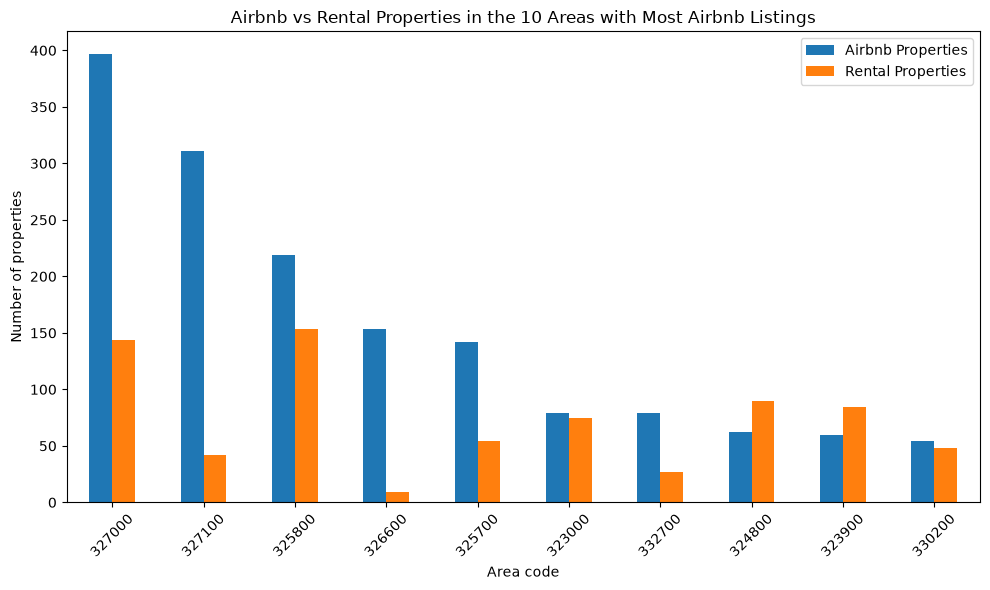

Graph saved to: /Users/oliverabbott/Desktop/GRP_Project_422_201/week_10/week_9


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1. FILE PATHS
# ==========================================

file_path = Path("../Output/christ_bond_merged.csv")

tenancy_file = Path(
    "/Users/oliverabbott/Desktop/"
    "Detailed-Quarterly-Tenancy-Q1-2020-Q3-2026.csv"
)

output_folder = Path("week_9")
output_folder.mkdir(exist_ok=True)


# ==========================================
# 2. LOAD MERGED DATASET
# ==========================================

data = pd.read_csv(file_path)




# ==========================================
# 3. COUNT AIRBNB AND RENTAL PROPERTIES
# ==========================================

def create_comparison(data):
    airbnb_counts = data.groupby("area_code")["id"].nunique()
    
    rental_counts = data.groupby("area_code")["Total Bonds"].max()
    
    comparison = pd.DataFrame({
        "Airbnb Properties": airbnb_counts,
        "Rental Properties": rental_counts
    })
    
    return comparison


comparison = create_comparison(data)

comparison


# ==========================================
# 4. CHECK MISSING RENTAL DATA
# ==========================================

areas_with_rent = comparison["Rental Properties"].notna().sum()

areas_without_rent = comparison["Rental Properties"].isna().sum()

print("Areas with rental data:", areas_with_rent)
print("Areas without rental data:", areas_without_rent)

missing_rent = comparison[comparison["Rental Properties"].isna()]

print("\nAreas with no rental data:")
display(missing_rent)

missing_codes = missing_rent.index

print("Number of missing area codes:", len(missing_codes))
print("Missing area codes:")
print(missing_codes.tolist())


# 


# ==========================================
# 6. CREATE FINAL COMPARISON TABLE
# ==========================================

comparison_complete = comparison.dropna(
    subset=["Rental Properties"]
).copy()

comparison_complete["Rental Properties"] = (
    comparison_complete["Rental Properties"].astype(int)
)

comparison_complete = comparison_complete.reset_index()

print("\nAirbnb properties vs rental properties by area:")

display(comparison_complete)


# ==========================================
# 7. SAVE COMPARISON TABLE
# ==========================================

comparison_complete.to_csv(
    output_folder / "airbnb_vs_rentals_by_area.csv",
    index=False
)

print("Comparison table saved to:", output_folder.resolve())


# ==========================================
# 8. TOP 10 AREAS BY AIRBNB PROPERTIES
# ==========================================

top_10 = comparison_complete.nlargest(
    10, "Airbnb Properties"
)

print("\nTop 10 areas by Airbnb properties:")

display(top_10)


# ==========================================
# 9. CREATE AND SAVE BAR CHART
# ==========================================

ax = top_10.plot(
    x="area_code",
    y=["Airbnb Properties", "Rental Properties"],
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Airbnb vs Rental Properties in the 10 Areas "
    "with Most Airbnb Listings"
)

plt.xlabel("Area code")
plt.ylabel("Number of properties")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    output_folder / "airbnb_vs_rentals_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved to:", output_folder.resolve())

##### I removed a repeated calculation of the Airbnb and rental property counts. the counts are now calculated once and the results are reused throughout the analysis

##### I created a function for generating the Airbnb and rental property comparison. This separates the calculation from the rest of the analysis and makes the code easier to reuse and maintain. The function can also be used with another dataset in the future without having to rewrite the calculation.

##### Removed unimportant code to make file smaller, was not needed because its already included in the cleaning proccess
